* Create Pytorch models.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np

### B1. Tensors and a manual training loop

In [ ]:
n_points = 100
torch.manual_seed(42)

noise = torch.rand(n_points)*0.001
x = torch.linspace(-10, 10, n_points) 
y = 2*x + 1 + noise

w = torch.tensor(0.0, requires_grad=True)
b = torch.tensor(0.0, requires_grad=True)

lr = 0.01 # learning rate
for epoch in range(10000):

    # forward
    y_pred = w * x + b    

    loss = F.mse_loss(y_pred, y)
    loss.backward()
    # print(loss.item())
    # if using an optimizer the manual update is not needed. With an optimizer it is done with optimizer.step()
    with torch.no_grad():
        w -= lr * w.grad
        b -= lr * b.grad

    # reset gradients. If using an optimizer done with optimizer.zero_grad().
    w.grad.zero_()
    b.grad.zero_()

print(w,b)

137.0268096923828
14.878715515136719
2.347254991531372
1.032444953918457
0.866547167301178
0.8194414377212524
0.7856826782226562
0.7544354796409607
0.7245460748672485
0.6958529949188232
0.6682970523834229
0.6418325304985046
0.616415798664093
0.5920059680938721
0.5685627460479736
0.5460469722747803
0.5244243144989014
0.5036566853523254
0.48371195793151855
0.46455711126327515
0.4461604952812195
0.42849257588386536
0.41152408719062805
0.3952277898788452
0.37957680225372314
0.36454543471336365
0.3501095473766327
0.33624541759490967
0.3229300379753113
0.31014207005500793
0.29786038398742676
0.28606483340263367
0.27473706007003784
0.2638576030731201
0.2534087002277374
0.2433735728263855
0.23373591899871826
0.22448015213012695
0.21559076011180878
0.20705343782901764
0.1988539695739746
0.19097943603992462
0.1834164559841156
0.17615322768688202
0.16917765140533447
0.16247829794883728
0.15604418516159058
0.14986491203308105
0.14393024146556854
0.13823044300079346
0.13275669515132904
0.1274994313

### B2. `nn.Module`, `nn.Sequential`, and a real optimizer


torch.Size([100, 1])
torch.Size([100, 1])
torch.Size([100, 1])
torch.Size([100, 1])
torch.Size([100, 1])
torch.Size([100, 1])
torch.Size([100, 1])
torch.Size([100, 1])
torch.Size([100, 1])
torch.Size([100, 1])
torch.Size([100, 1])
torch.Size([100, 1])
torch.Size([100, 1])
torch.Size([100, 1])
torch.Size([100, 1])
torch.Size([100, 1])
torch.Size([100, 1])
torch.Size([100, 1])
torch.Size([100, 1])
torch.Size([100, 1])
torch.Size([100, 1])
torch.Size([100, 1])
torch.Size([100, 1])
torch.Size([100, 1])
torch.Size([100, 1])
torch.Size([100, 1])
torch.Size([100, 1])
torch.Size([100, 1])
torch.Size([100, 1])
torch.Size([100, 1])
torch.Size([100, 1])
torch.Size([100, 1])
torch.Size([100, 1])
torch.Size([100, 1])
torch.Size([100, 1])
torch.Size([100, 1])
torch.Size([100, 1])
torch.Size([100, 1])
torch.Size([100, 1])
torch.Size([100, 1])
torch.Size([100, 1])
torch.Size([100, 1])
torch.Size([100, 1])
torch.Size([100, 1])
torch.Size([100, 1])
torch.Size([100, 1])
torch.Size([100, 1])
torch.Size([1

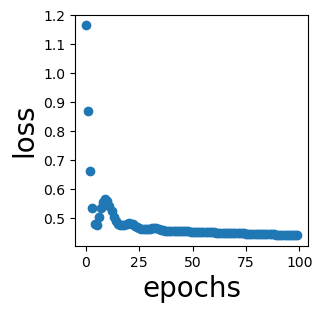

In [18]:
# 2-layer MLP

class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
                                    nn.Linear(1,10),
                                    nn.ReLU(),
                                    nn.Linear(10,1)
                                )
    def forward(self,x):
        return self.model(x)

# instantiate model
model = MLP()

# generate data
n_points = 100
n_epochs = 100
noise = (torch.rand(n_points,1)*0.01)
x = torch.linspace(-10, 10, n_points).reshape(-1,1)
y = torch.sin(x) + noise

# define optimizer
lr = 0.01
opt = torch.optim.AdamW(model.parameters(), lr=lr,
                               weight_decay=1e-4)

losses = []
for epoch in range(n_epochs):
    # forward
    y_pred = model(x)

    # clean gradients
    opt.zero_grad()
    # compute the loss
    loss = F.mse_loss(y_pred, y)
    loss.backward()
    losses.append(loss.item())
    # update parameters
    opt.step()

fig, ax = plt.subplots(figsize=(3,3))

ax.scatter(x=np.arange(n_points),y=losses)
ax.set_xlabel("epochs",fontsize=20)
ax.set_ylabel("loss",fontsize=20)
plt.show()

### B3. Encoding different modalities

In [29]:
class ImageEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn1 = nn.Sequential(
            nn.Conv2d(in_channels=3,out_channels=8,kernel_size=2,stride=2),
            nn.ReLU())
        
        self.cnn2 = nn.Sequential(
            nn.Conv2d(in_channels=8,out_channels=16,kernel_size=2,stride=2),
            nn.ReLU())

        self.cnn3 = nn.Sequential(
            nn.Conv2d(in_channels=16, out_channels=32,kernel_size=2,stride=2),
            nn.ReLU())

        self.cnn4 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64,kernel_size=2,stride=2),
            nn.ReLU())

        self.flatten = nn.Sequential(nn.Flatten(), nn.Linear(64*4*4, 64))

    def forward(self, x):
        x = self.cnn1(x)
        # print(x.shape)
        x = self.cnn2(x)
        # print(x.shape)
        x = self.cnn3(x)
        # print(x.shape)
        x = self.cnn4(x)
        # print(x.shape)
        x = self.flatten(x)
        # print(x.shape)
        return x

class StateEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.mlp = nn.Sequential(
                                nn.Linear(in_features=10, out_features=32),
                                nn.ReLU()
                                )


    def forward(self, x):
        # print(self.mlp(x).shape)
        return self.mlp(x)

class CombinedModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.image_encoder = ImageEncoder()
        self.state_encoder = StateEncoder()

    def forward(self, img, state):
        image_features = self.image_encoder(img)
        state_features = self.state_encoder(state)

        return torch.cat([image_features, state_features], dim=1)



# generate data
img = torch.randn(8,3,64,64)
state = torch.randn(8,10)
combined_model = CombinedModel()
combined_features = combined_model(img, state)
print(combined_features.shape)

torch.Size([8, 96])


### B4. A classifier with temporal input

 * when timesteps are reduced the performance of the model decreases

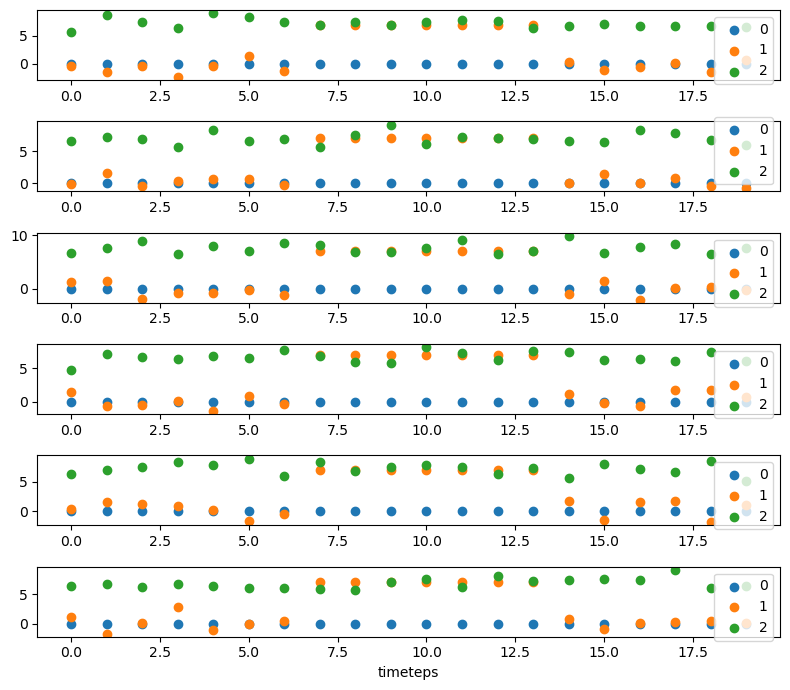

In [137]:
# generate synthetic data
torch.manual_seed(42)

def generate_synthetic_data(timesteps, channels, class_label):

    signal = torch.randn((timesteps,channels))

    if class_label == 0:
        signal = signal[:,:]*0.00001

    elif class_label == 1:
        signal[7:14,:] = 7.0

    elif class_label == 2:
        signal += 7.0

    return signal

def sample_multiple_signals(n_signals, timesteps, channels):
    # initialize
    X = torch.zeros((n_signals,timesteps,channels))
    y = torch.randint(low=0,high=3, size=(n_signals,)) # classes: 0,1,2

    for idx_signal in range(n_signals):
        X[idx_signal,:,:] = generate_synthetic_data(timesteps, channels, y[idx_signal].item())

    return X, y


timesteps = 20
channels = 6
class_label = 0

# plot the 3 classes.
fig, ax = plt.subplots(nrows=channels,ncols=1,figsize=(8,7))

for channel_index in range(channels):
    for class_label in range(3):
        ax[channel_index].scatter(x=np.arange(timesteps), y=generate_synthetic_data(timesteps,channels,class_label)[:,channel_index], label=class_label)
        ax[channel_index].legend()

ax[channel_index].set_xlabel("timeteps")
fig.tight_layout()
plt.show()

In [163]:
# Build classifier
class ConvClassifier(nn.Module):
    def __init__(self,timesteps):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels=6, out_channels=16,kernel_size=1), # in_channels=channels, which are 6
            nn.ReLU(),
            nn.Conv1d(in_channels=16, out_channels=32,kernel_size=1),
            nn.ReLU(),
            nn.Flatten()
        )
        self.fc = nn.Linear(in_features=32*timesteps, out_features=3)

    def forward(self, x):
        x = self.cnn(x)
        x = self.fc(x)
        return x

In [173]:
n_signals = 128
timesteps = 2
channels = 6

# Generate the signals X, and the classes to predict y.
X, y = sample_multiple_signals(n_signals, timesteps, channels)
print(X.shape, y.shape)

# permute in order to make the signal X compatible with Conv1d.
X = X.permute(0,2,1) # Conv1d takes (batch,channels,timesteps), not (batch,timesteps,channels)
print(X.shape)
dataset = TensorDataset(X,y)

# proportion of data on training and testing phase.
train_size = int(0.80 * len(dataset))
test_size = len(dataset) - train_size

train_ds, test_ds = random_split(dataset, [train_size, test_size])

train_dataloader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_dataloader = DataLoader(test_ds, batch_size=32)

torch.Size([128, 2, 6]) torch.Size([128])
torch.Size([128, 6, 2])


In [174]:
model = ConvClassifier(timesteps)
lr = 0.01
opt = torch.optim.AdamW(model.parameters(), lr=lr,
                               weight_decay=1e-4)
                               

In [175]:
accuracies = []
for epoch in range(50):
    total_loss = 0
    correct = 0
    total_predictions = 0 # accuracy is calculated as how many of the total_predictions were right.
    for signals, labels in train_dataloader:
        opt.zero_grad()

        logits = model(signals)

        loss = F.cross_entropy(logits, labels)

        loss.backward()

        opt.step()

        total_loss += loss.item()

        predictions = torch.argmax(logits, dim=1)
        # print(predictions == labels)
        correct += (predictions == labels).sum().item()
        # print(logits.shape, labels.shape, predictions.shape, labels.size(0))
        total_predictions += labels.size(0)

    accuracy = correct / total_predictions
    accuracies.append(accuracy)
    if epoch % 10 == 0:
        print(
        f"Epoch {epoch+1}: "
        f"loss={total_loss:.3f}, "
        f"accuracy={accuracy:.3f}"
    )

# fig, ax = plt.subplots(figsize=(5,5))
# ax.scatter(np.arange(len(accuracies)),accuracies)

Epoch 1: loss=4.253, accuracy=0.608
Epoch 11: loss=0.284, accuracy=0.990
Epoch 21: loss=0.008, accuracy=1.000
Epoch 31: loss=0.003, accuracy=1.000
Epoch 41: loss=0.002, accuracy=1.000


In [176]:
# test classifier on held-out data

correct = 0
total = 0

with torch.no_grad():

    for signals, labels in test_dataloader:

        logits = model(signals)

        predictions = torch.argmax(
            logits,
            dim=1
        )

        correct += (predictions == labels).sum().item()
        total += labels.size(0)


print("Test accuracy:", correct/total)

Test accuracy: 0.9615384615384616


### B5. Regression baseline for actions


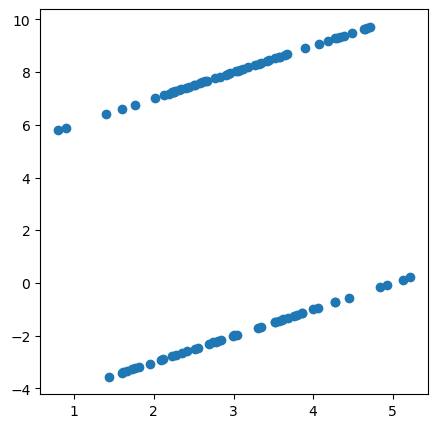

In [65]:
# generate synthetic data
torch.manual_seed(42)

n_points = 100
x = (torch.randn(n_points) + 3).reshape(-1,1)
y = torch.zeros(n_points).reshape(-1,1)

for idx in range(n_points):
    if torch.rand(1) < 0.50:
        y[idx] = x[idx] + 5
    else:
        y[idx] = x[idx] - 5

fix, ax = plt.subplots(figsize=(5,5))
ax.scatter(x,y)
plt.show()

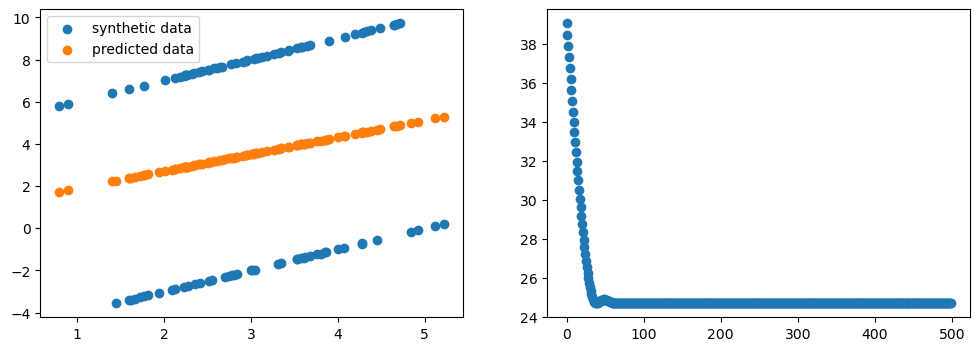

In [97]:
class ActionClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.mlp = nn.Sequential(nn.Linear(1,10),nn.ReLU(),nn.Linear(10,1))
    
    def forward(self, x):
        return self.mlp(x)

model = ActionClassifier()

# optimizer
lr = 0.01
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
losses = []
for epoch in range(500):
    optimizer.zero_grad()

    y_pred = model(x)
    loss = F.mse_loss(y_pred, y)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

# plot together y and y_pred
fig, ax = plt.subplots(ncols=2, figsize=(12,4))
ax[0].scatter(x.detach().numpy(),y.detach().numpy(),label="synthetic data")
ax[0].scatter(x.detach().numpy(),y_pred.detach().numpy(),label="predicted data")
ax[0].legend()

ax[1].scatter(np.arange(len(losses)),losses)
plt.show()

### B6. Minimal diffusion model (1D toy version)


In [ ]:
class DiffusionModel(nn.Module):
    N_DIFFUSION_STEPS = 50

    def __init__(self):
        super().__init__()
        self.noise_net = nn.Sequential(
                                    nn.Linear(2,64),
                                    nn.ReLU(),
                                    nn.Linear(64,64),
                                    nn.ReLU(),
                                    nn.Linear(64,1)
                                    )
        
        # linear noise schedule
        betas     = torch.linspace(1e-4, 0.02, self.N_DIFFUSION_STEPS)
        alphas    = 1.0 - betas
        alpha_bar = torch.cumprod(alphas, dim=0)
        self.register_buffer("betas",     betas) # register_buffer: registers a tensor as part of your model, without making it a trainable parameter.
        self.register_buffer("alphas",    alphas)
        self.register_buffer("alpha_bar", alpha_bar)

    def forward(self, x_t, t):
        t = t.float().unsqueeze(1)        
        inp = torch.cat([x_t,t], dim=1)
        return self.noise_net(inp)
    
    @torch.no_grad()
    def sample(self, n):
        x = torch.randn(n,1)

        for t in reversed(range(self.N_DIFFUSION_STEPS)):

            t_batch = torch.ones(n,1)*t
            inp = torch.cat([x,t_batch], dim=1)
            predicted_noise = self.noise_net(inp)

            alpha = self.alphas[t]
            alpha_bar = self.alpha_bar[t]
            beta = self.betas[t]

            x = (1/alpha.sqrt()*(x - beta / (1-alpha_bar).sqrt() * predicted_noise)) # from models.py: (x - (1 - alpha) / (1 - ab).sqrt() * predicted_noise) / alpha.sqrt()
            
            if t > 0:
                x += beta.sqrt()*torch.randn_like(x)
        return x

torch.Size([100, 1])
torch.Size([200, 1])


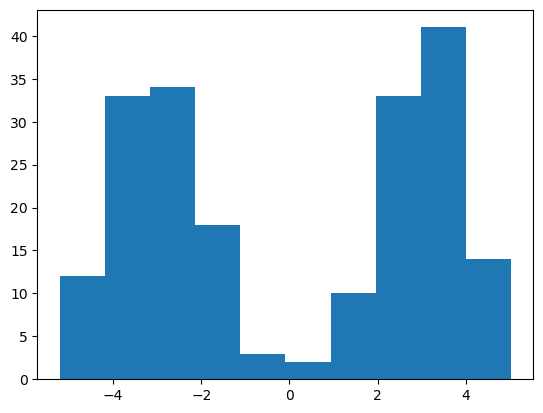

In [235]:
# sample two blobs
torch.manual_seed(42)
n_points = 200

blob1 = torch.randn(n_points//2, 1) - 3 # mu = -3
blob2 = torch.randn(n_points//2, 1) + 3 # mu =  3

# print(blob1.shape)
x = torch.cat([blob1, blob2], dim=0)
# print(x.shape)
plt.hist(x.numpy())
plt.show()

# define model and optimizer
model = DiffusionModel()
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

In [ ]:
losses = []

for epoch in range(10000):
    t_idx = torch.randint(0, model.N_DIFFUSION_STEPS,(x.shape[0],))
    
    optimizer.zero_grad()
    
    # add noise to the action
    ab = model.alpha_bar[t_idx].unsqueeze(1)
    noise = torch.randn_like(x)
    x_t = ab.sqrt() * x + (1 - ab).sqrt() * noise
    
    # predict the noise
    pred_noise = model(x_t, t_idx)
    
    # compute the loss
    loss = F.mse_loss(pred_noise, noise) # the MSE is between the predicted noisy action x_t, and the true added noise.
    loss.backward()

    optimizer.step()
    losses.append(loss.item())

# sample from model
x_pred = model.sample(n_points)

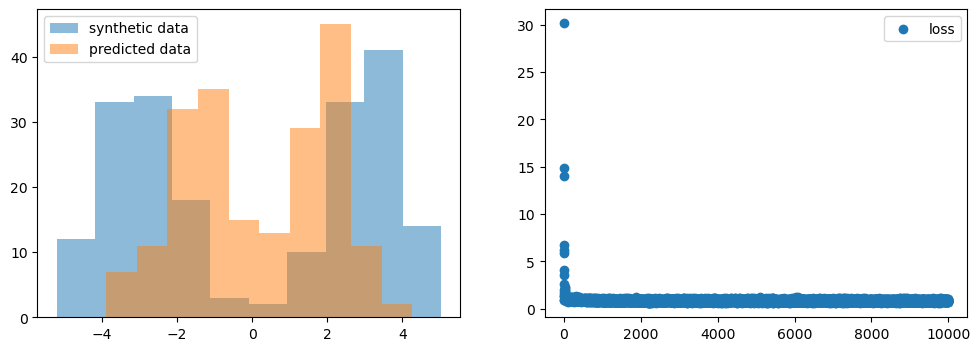

In [193]:
# plot together y and y_pred
fig, ax = plt.subplots(ncols=2, figsize=(12,4))
ax[0].hist(x.detach().numpy(), alpha=0.5, label="synthetic data")
ax[0].hist(x_pred.detach().numpy(), alpha=0.5,label="predicted data")
ax[0].legend()

ax[1].scatter(np.arange(len(losses)),losses, label="loss")
ax[1].legend()

plt.show()

### B7. Conditioning the diffusion model

* The model performance improved when changing in the model that the embedding of the condition (0,1,2) is done with nn.Embedding instead of the nn.Linear
    * Performance is assessed by looking at whether the sampled data from the converged model generates the three patterns:
        * c=0 => Data around +5
        * c=1 => Data around -5
        * c=2 => Data around +5 and -5 with 50% prob.

In [371]:
class DiffusionModelCond(nn.Module):
    N_DIFFUSION_STEPS = 50
    COND_EMB_DIM = 16

    def __init__(self):
        super().__init__()
        # self.fc = nn.Sequential(
        #                             nn.Linear(1,64),
        #                             nn.ReLU(),
        #                             nn.Linear(64, self.COND_EMB_DIM)
        #                         )

        self.cond_embed = nn.Embedding(3, self.COND_EMB_DIM)

        self.noise_net = nn.Sequential(
                                    nn.Linear(2 + self.COND_EMB_DIM,64),
                                    nn.ReLU(),
                                    nn.Linear(64,64),
                                    nn.ReLU(),
                                    nn.Linear(64,1)
                                    )
        
        # linear noise schedule
        betas     = torch.linspace(1e-4, 0.02, self.N_DIFFUSION_STEPS)
        alphas    = 1.0 - betas
        alpha_bar = torch.cumprod(alphas, dim=0)
        self.register_buffer("betas",     betas) # register_buffer: registers a tensor as part of your model, without making it a trainable parameter.
        self.register_buffer("alphas",    alphas)
        self.register_buffer("alpha_bar", alpha_bar)

    def forward(self, x_t, t, c):
        t = t.float().unsqueeze(1) / self.N_DIFFUSION_STEPS
        cond_emb = self.cond_embed(c.long()) # embedding conditioning
        inp = torch.cat([x_t,t,cond_emb], dim=1)
        return self.noise_net(inp)
    
    @torch.no_grad()
    def sample(self, n, c):
        x = torch.randn(n,1)
        cond_emb = self.cond_embed(c.long())

        for t in reversed(range(self.N_DIFFUSION_STEPS)):
            t_batch = torch.ones(n,1)*t / self.N_DIFFUSION_STEPS
            inp = torch.cat([x, t_batch, cond_emb], dim=1)
            predicted_noise = self.noise_net(inp)

            alpha = self.alphas[t]
            alpha_bar = self.alpha_bar[t]
            beta = self.betas[t]

            x = (1/alpha.sqrt()*(x - beta / (1-alpha_bar).sqrt() * predicted_noise)) # from models.py: (x - (1 - alpha) / (1 - ab).sqrt() * predicted_noise) / alpha.sqrt()
            
            if t > 0:
                x += beta.sqrt()*torch.randn_like(x)
        return x

torch.Size([200])


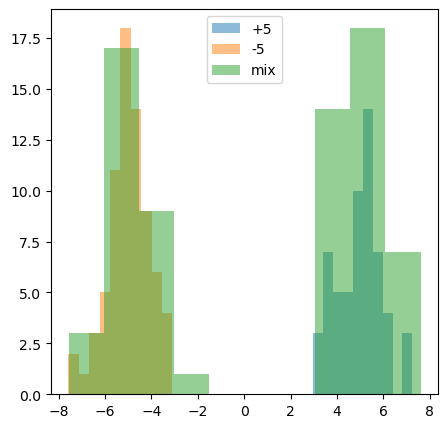

In [372]:
# generate synthetic data
torch.manual_seed(42)

n_points = 200
c = torch.randint(0, 3,(n_points,))

idx_0 = torch.where(c == 0)[0]
idx_1 = torch.where(c == 1)[0]
idx_2 = torch.where(c == 2)[0]

# generate y
y = torch.zeros(n_points)
y[idx_0] = torch.randn(len(idx_0)) + 5
y[idx_1] = torch.randn(len(idx_1)) - 5
for idx in idx_2:
    if torch.rand(1) < 0.50:
        y[idx] = torch.randn(1) + 5
    else:
        y[idx] = torch.randn(1) - 5

y = y.reshape(-1,1)
# c = c.reshape(-1,1)
print(c.shape)

# plot data
fix, ax = plt.subplots(figsize=(5,5))
for idx, label in [(idx_0, "+5"), (idx_1, "-5"), (idx_2, "mix")]:
    ax.hist(y.numpy()[idx], alpha=0.5, label=label)
ax.legend()
plt.show()

# define model and optimizer
model = DiffusionModelCond()
lr=0.01
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.0)

In [373]:
losses = []

for epoch in range(20000):
    t_idx = torch.randint(0, model.N_DIFFUSION_STEPS,(y.shape[0],))
    
    optimizer.zero_grad()
    
    # add noise to the action
    ab = model.alpha_bar[t_idx].unsqueeze(1)
    noise = torch.randn_like(y)
    y_t = ab.sqrt() * y + (1 - ab).sqrt() * noise
    
    # predict the noise
    pred_noise = model(y_t, t_idx, c)
    
    # compute the loss
    loss = F.mse_loss(pred_noise, noise) # the MSE is between the predicted noisy action x_t, and the true added noise.
    loss.backward()

    # update the network
    optimizer.step()
    losses.append(loss.item())

In [374]:
# inspect whether the conditioning embedding differiates between conditions.
with torch.no_grad():
    for cv in [0, 1, 2]:
        print(cv, model.cond_embed(torch.tensor([cv])))

0 tensor([[ 0.0135,  0.0359, -2.0715,  1.0450,  0.0429, -0.6721, -0.0324,  0.0244,
         -0.0104,  0.0235, -0.0110, -0.0265, -0.0242,  0.0067,  0.0232,  0.0217]])
1 tensor([[-5.1739e-05,  1.0007e-01,  1.0640e+00, -2.4921e+00,  2.3550e-01,
         -3.4775e-01, -1.5988e-03, -9.6333e-03,  5.7308e-03,  5.0800e-03,
          1.1871e-02,  6.5387e-03, -1.0359e-02, -3.9211e-03,  1.6970e-03,
         -5.9478e-03]])
2 tensor([[-0.0034, -0.0091, -0.1709, -0.1825, -1.2416,  1.3488,  0.0133, -0.0073,
          0.0034,  0.0165,  0.0213,  0.0108, -0.0188, -0.0024,  0.0084, -0.0064]])


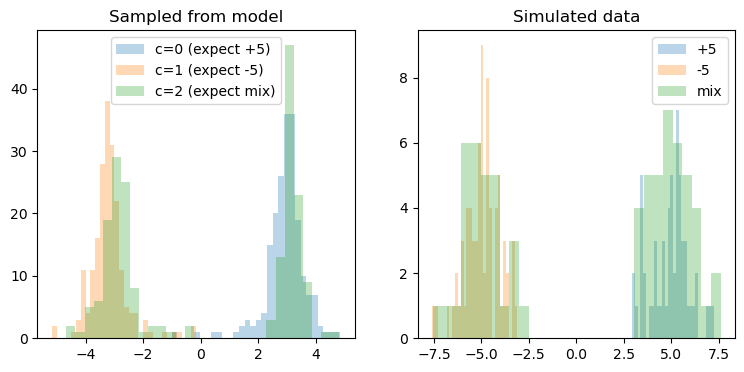

In [375]:
# sampling and plotting
fix, ax = plt.subplots(ncols=2,figsize=(9,4))

for cond_val, label in [(0, "+5"), (1, "-5"), (2, "mix")]:
    y_pred = model.sample(n_points, torch.zeros(n_points) + cond_val)
    ax[0].hist(y_pred.numpy(), bins=30, alpha=0.3, label=f"c={cond_val} (expect {label})")

for idx, label in [(idx_0, "+5"), (idx_1, "-5"), (idx_2, "mix")]:
    ax[1].hist(y.numpy()[idx], bins=30, alpha=0.3, label=label)


ax[0].set_title("Sampled from model")
ax[1].set_title("Simulated data")

ax[0].legend()
ax[1].legend()
plt.show()